# Medical Insurance Cost Prediction using Multiple Linear Regression

**Assignment 1 — AI/ML**

**Objective:** Build a Multiple Linear Regression model that predicts a person's
medical insurance charges from their personal and health-related attributes.

**Dataset:** [Medical Cost Personal Insurance Dataset (Kaggle)](https://www.kaggle.com/datasets/mirichoi0218/insurance)


## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)


In [2]:
# Load the dataset
df = pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Basic info about the dataset
print("Shape:", df.shape)
df.info()


Shape: (1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


**Feature identification**

| Type | Columns |
|---|---|
| Numerical features | `age`, `bmi`, `children` |
| Categorical features | `sex`, `smoker`, `region` |
| Target variable | `charges` |


In [4]:
numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']
target_variable = 'charges'

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target variable:", target_variable)


Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']
Target variable: charges


## Task 2: Data Preprocessing

In [5]:
# Check for missing values
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
# Encode categorical variables
# sex, smoker -> binary encoding via one-hot (drop_first=True)
# region -> one-hot encoding (drop_first=True)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
df_encoded.head()


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [7]:
# Split features/target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (1070, 8)
Testing set shape: (268, 8)


## Task 3: Model Development

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df.loc[len(coef_df)] = ['Intercept', model.intercept_]
coef_df


,Feature,Coefficient
0,age,256.975706
1,bmi,337.092552
2,children,425.278784
3,sex_male,-18.591692
4,smoker_yes,23651.128856
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354
8,Intercept,-11931.219050


In [9]:
# Preview of actual vs predicted charges on the test set
results_preview = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred}).head(10)
results_preview


,Actual,Predicted
0,9095.06825,8969.550274
1,5272.17580,7068.747443
2,29330.98315,36858.410912
3,9301.89355,9454.678501
4,33750.29180,26973.173457
5,4536.25900,10864.113164
6,2117.33885,170.280841
7,14210.53595,16903.450287
8,3732.62510,1092.430936
9,10264.44210,11218.343184


## Task 4: Model Evaluation

In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")


Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
Root Mean Squared Error (RMSE): 5796.28
R-squared (R2 Score): 0.7836


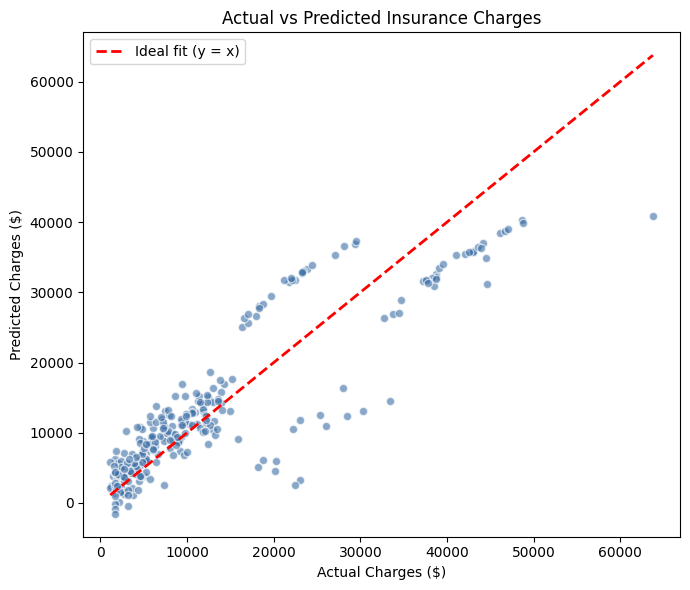

In [11]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#3b6ea5', edgecolor='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal fit (y = x)')
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend()
plt.tight_layout()
plt.show()


### Observations

1. **Smoking status dominates the model.** The `smoker_yes` coefficient (~+23,650) is
   an order of magnitude larger than any other feature, confirming that smokers are
   charged dramatically more than non-smokers, all else equal.
2. **Age, BMI, and number of children all push charges up modestly** (small positive
   coefficients), which matches the real-world intuition that older age, higher BMI,
   and more dependents increase expected medical cost.
3. **The model explains a good share of the variance (R² ≈ 0.78)** but the scatter plot
   shows a visible upper cluster of under-predicted points — mostly high-charge smokers —
   meaning a chunk of the variance is not captured by a purely linear/additive model.


## Task 5: Conclusion

This project used Multiple Linear Regression to predict medical insurance charges
from age, sex, BMI, number of children, smoking status, and region. After encoding the
categorical variables and splitting the data 80/20, the model achieved an R² score of
about 0.78 on the test set, meaning it explains roughly 78% of the variance in charges.
Smoking status was by far the strongest predictor, followed by age and BMI, which aligns
with known medical cost drivers — smoking, aging, and obesity all raise health risk and
therefore insurance cost. Region and sex had comparatively minor effects. A key limitation
of Linear Regression here is that it assumes a purely linear, additive relationship between
features and charges, but the real cost structure is better described by interaction
effects (e.g., smoking combined with high BMI multiplies risk rather than just adding to
it) and is naturally right-skewed, which a straight-line model cannot fully capture. This
suggests that models such as polynomial regression, regularized regression with
interaction terms, or tree-based ensembles (e.g., Random Forest, Gradient Boosting) could
improve predictive accuracy.
